In [ ]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


In [ ]:
# Cargar dataset limpio
df = pd.read_csv('gasolina_master_limpio.csv', parse_dates=['Fecha'])

print("📊 DATASET CARGADO")
print("="*70)
print(f"Registros: {len(df)}")
print(f"Periodo: {df['Fecha'].min().date()} a {df['Fecha'].max().date()}")
print(f"\n📋 Columnas actuales:")
print(df.columns.tolist())
print(f"\n🔍 Info del dataset:")
print(df.info())
print(f"\n📈 Primeros registros:")
print(df.head())

📊 DATASET CARGADO
Registros: 263
Periodo: 2017-12-31 a 2025-12-13

📋 Columnas actuales:
['Kilometros', 'Litros', 'Pago', 'Precio', 'Fecha', 'Año', 'km_diff']

🔍 Info del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Kilometros  263 non-null    float64       
 1   Litros      263 non-null    float64       
 2   Pago        263 non-null    float64       
 3   Precio      263 non-null    float64       
 4   Fecha       263 non-null    datetime64[ns]
 5   Año         263 non-null    int64         
 6   km_diff     39 non-null     float64       
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 14.5 KB
None

📈 Primeros registros:
   Kilometros  Litros   Pago  Precio      Fecha   Año  km_diff
0     42998.0    16.3  270.0   16.57 2017-12-31  2018      NaN
1     43249.0    19.0  290.0   16.78 2018-01-09  2018      Na

In [ ]:
# INGENIERÍA DE FEATURES - PARTE 1: DISTANCIA
print("\n🚗 CALCULANDO VARIABLES DE DISTANCIA")
print("="*70)

# 1. Kilómetros recorridos entre recargas
df['km_recorridos'] = df['Kilometros'].diff()

# El primer registro no tiene km previo, asignar NaN o 0
# (lo manejaremos después)

# 2. Kilómetros acumulados desde el inicio
df['km_acumulados'] = df['Kilometros'] - df['Kilometros'].iloc[0]

print("✅ Variables de distancia creadas:")
print("   - km_recorridos (entre recargas)")
print("   - km_acumulados (desde inicio)")

# Verificar
print(f"\n📊 Primeros 10 registros con nuevas variables:")
print(df[['Fecha', 'Kilometros', 'km_recorridos', 'km_acumulados', 'Litros']].head(10))

# Estadísticas
print(f"\n📈 Estadísticas de km_recorridos:")
print(df['km_recorridos'].describe())


🚗 CALCULANDO VARIABLES DE DISTANCIA
✅ Variables de distancia creadas:
   - km_recorridos (entre recargas)
   - km_acumulados (desde inicio)

📊 Primeros 10 registros con nuevas variables:
       Fecha  Kilometros  km_recorridos  km_acumulados  Litros
0 2017-12-31     42998.0            NaN            0.0    16.3
1 2018-01-09     43249.0          251.0          251.0    19.0
2 2018-01-22     43486.0          237.0          488.0    18.5
3 2018-01-29     43759.0          273.0          761.0    19.6
4 2018-02-04     43859.0          100.0          861.0     8.9
5 2018-02-12     44123.0          264.0         1125.0    18.5
6 2018-02-27     44368.0          245.0         1370.0    16.6
7 2018-03-04     44449.0           81.0         1451.0    14.1
8 2018-03-12     44717.0          268.0         1719.0    19.9
9 2018-03-26     44957.0          240.0         1959.0    16.5

📈 Estadísticas de km_recorridos:
count    262.000000
mean     271.164122
std      117.084873
min      -70.000000
25%  

In [ ]:
# INGENIERÍA DE FEATURES - PARTE 2: EFICIENCIA
print("\n⛽ CALCULANDO VARIABLES DE EFICIENCIA")
print("="*70)

# 1. Rendimiento (km por litro)
df['rendimiento_kml'] = df['km_recorridos'] / df['Litros']

# 2. Promedio histórico de rendimiento (excluyendo NaN)
promedio_rendimiento = df['rendimiento_kml'].mean()

# 3. Eficiencia relativa (% vs promedio histórico)
df['eficiencia_relativa'] = ((df['rendimiento_kml'] - promedio_rendimiento) / promedio_rendimiento) * 100

print("✅ Variables de eficiencia creadas:")
print(f"   - rendimiento_kml: {promedio_rendimiento:.2f} km/L (promedio)")
print("   - eficiencia_relativa (% vs histórico)")

# Verificar
print(f"\n📊 Muestra de eficiencia:")
print(df[['Fecha', 'km_recorridos', 'Litros', 'rendimiento_kml', 'eficiencia_relativa']].head(10))

# Estadísticas
print(f"\n📈 Estadísticas de rendimiento:")
print(df['rendimiento_kml'].describe())

# Identificar mejor y peor rendimiento
mejor_rendimiento = df.loc[df['rendimiento_kml'].idxmax()]
peor_rendimiento = df.loc[df['rendimiento_kml'].idxmin()]

print(f"\n🏆 Mejor rendimiento: {mejor_rendimiento['rendimiento_kml']:.2f} km/L el {mejor_rendimiento['Fecha'].date()}")
print(f"⚠️  Peor rendimiento: {peor_rendimiento['rendimiento_kml']:.2f} km/L el {peor_rendimiento['Fecha'].date()}")


⛽ CALCULANDO VARIABLES DE EFICIENCIA
✅ Variables de eficiencia creadas:
   - rendimiento_kml: 14.78 km/L (promedio)
   - eficiencia_relativa (% vs histórico)

📊 Muestra de eficiencia:
       Fecha  km_recorridos  Litros  rendimiento_kml  eficiencia_relativa
0 2017-12-31            NaN    16.3              NaN                  NaN
1 2018-01-09          251.0    19.0        13.210526           -10.617921
2 2018-01-22          237.0    18.5        12.810811           -13.322385
3 2018-01-29          273.0    19.6        13.928571            -5.759646
4 2018-02-04          100.0     8.9        11.235955           -23.977819
5 2018-02-12          264.0    18.5        14.270270            -3.447720
6 2018-02-27          245.0    16.6        14.759036            -0.140743
7 2018-03-04           81.0    14.1         5.744681           -61.131638
8 2018-03-12          268.0    19.9        13.467337            -8.880348
9 2018-03-26          240.0    16.5        14.545455            -1.585831



🔍 INVESTIGACIÓN DE RENDIMIENTO

📊 Distribución de rendimiento:
count    262.000000
mean      14.779838
std       10.721650
min      -11.666667
5%         2.572821
10%        5.025526
25%       10.985169
50%       12.866601
75%       14.973887
90%       27.069747
95%       33.499699
max       79.047619
Name: rendimiento_kml, dtype: float64

⚠️  Outliers detectados (método IQR):
   Límite inferior: 5.00 km/L
   Límite superior: 20.96 km/L
   Total de outliers: 68 de 263 registros (25.9%)

🔍 Registros con rendimiento anormal:
         Fecha  km_recorridos  Litros  rendimiento_kml
203 2024-03-10          332.0     4.2        79.047619
188 2023-10-21          625.0     8.0        78.125000
153 2022-11-20          367.0     6.0        61.166667
56  2019-09-11          360.0     6.8        52.941176
166 2023-04-27          417.0     8.0        52.125000
..         ...            ...     ...              ...
127 2021-12-25            0.0    24.0         0.000000
99  2020-12-27            0.0  

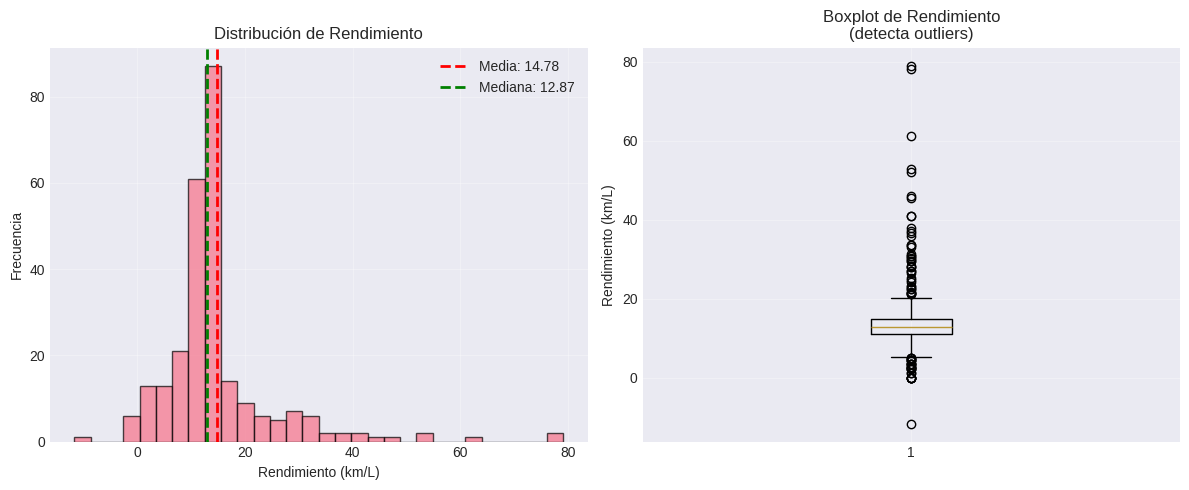


📈 COMPARACIÓN ESTADÍSTICA:
   Media (promedio): 14.78 km/L
   Mediana (valor central): 12.87 km/L
   Moda (más frecuente): 0.00 km/L

💡 Si la media es muy diferente a la mediana, hay outliers influyendo

📅 RENDIMIENTO PROMEDIO POR AÑO:
           mean     median  count
Año                              
2018  12.967883  12.810811     35
2019  12.827193  11.598361     31
2020  13.031287  12.815152     32
2021  14.169305  12.825855     28
2022  15.751939  13.292342     30
2023  17.353182  13.429435     40
2024  16.927063  12.583333     35
2025  14.449169  12.869565     31


In [ ]:
# INVESTIGACIÓN: ¿Por qué el promedio es tan alto?
print("🔍 INVESTIGACIÓN DE RENDIMIENTO")
print("="*70)

# 1. Distribución del rendimiento
print(f"\n📊 Distribución de rendimiento:")
print(df['rendimiento_kml'].describe(percentiles=[.05, .10, .25, .50, .75, .90, .95]))

# 2. Detectar outliers (valores extremos)
Q1 = df['rendimiento_kml'].quantile(0.25)
Q3 = df['rendimiento_kml'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df['rendimiento_kml'] < limite_inferior) | (df['rendimiento_kml'] > limite_superior)]

print(f"\n⚠️  Outliers detectados (método IQR):")
print(f"   Límite inferior: {limite_inferior:.2f} km/L")
print(f"   Límite superior: {limite_superior:.2f} km/L")
print(f"   Total de outliers: {len(outliers)} de {len(df)} registros ({len(outliers)/len(df)*100:.1f}%)")

if len(outliers) > 0:
    print(f"\n🔍 Registros con rendimiento anormal:")
    print(outliers[['Fecha', 'km_recorridos', 'Litros', 'rendimiento_kml']].sort_values('rendimiento_kml', ascending=False))

# 3. Histograma de rendimiento
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['rendimiento_kml'].dropna(), bins=30, edgecolor='black', alpha=0.7)
plt.axvline(df['rendimiento_kml'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["rendimiento_kml"].mean():.2f}')
plt.axvline(df['rendimiento_kml'].median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: {df["rendimiento_kml"].median():.2f}')
plt.xlabel('Rendimiento (km/L)')
plt.ylabel('Frecuencia')
plt.title('Distribución de Rendimiento')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot(df['rendimiento_kml'].dropna())
plt.ylabel('Rendimiento (km/L)')
plt.title('Boxplot de Rendimiento\n(detecta outliers)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Comparar media vs mediana
print(f"\n📈 COMPARACIÓN ESTADÍSTICA:")
print(f"   Media (promedio): {df['rendimiento_kml'].mean():.2f} km/L")
print(f"   Mediana (valor central): {df['rendimiento_kml'].median():.2f} km/L")
print(f"   Moda (más frecuente): {df['rendimiento_kml'].mode().values[0]:.2f} km/L")
print(f"\n💡 Si la media es muy diferente a la mediana, hay outliers influyendo")

# 5. Rendimiento por año
print(f"\n📅 RENDIMIENTO PROMEDIO POR AÑO:")
rendimiento_anual = df.groupby('Año')['rendimiento_kml'].agg(['mean', 'median', 'count'])
print(rendimiento_anual)

In [ ]:
# ESTRATEGIA: Marcar outliers pero mantenerlos
print("🏷️  CLASIFICACIÓN DE REGISTROS")
print("="*70)

# Crear flag de outlier
Q1 = df['rendimiento_kml'].quantile(0.25)
Q3 = df['rendimiento_kml'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

df['es_outlier'] = ((df['rendimiento_kml'] < limite_inferior) |
                     (df['rendimiento_kml'] > limite_superior))

# Clasificar tipo de recarga por distancia
df['tipo_recarga'] = pd.cut(df['km_recorridos'],
                             bins=[0, 100, 300, 1000],
                             labels=['Corta (<100km)', 'Media (100-300km)', 'Larga (>300km)'])

print(f"✅ Variables de clasificación creadas:")
print(f"   - es_outlier: {df['es_outlier'].sum()} outliers identificados")
print(f"   - tipo_recarga: clasificación por distancia")

# Comparación de métricas
print(f"\n📊 COMPARACIÓN DE MÉTRICAS:")
print(f"\n🔵 Dataset Completo (n={len(df)}):")
print(f"   Media: {df['rendimiento_kml'].mean():.2f} km/L")
print(f"   Mediana: {df['rendimiento_kml'].median():.2f} km/L")

df_sin_outliers = df[~df['es_outlier']]
print(f"\n🟢 Dataset Filtrado (n={len(df_sin_outliers)}):")
print(f"   Media: {df_sin_outliers['rendimiento_kml'].mean():.2f} km/L")
print(f"   Mediana: {df_sin_outliers['rendimiento_kml'].median():.2f} km/L")

# Rendimiento por tipo de recarga
print(f"\n📊 RENDIMIENTO POR TIPO DE RECARGA:")
print(df.groupby('tipo_recarga')['rendimiento_kml'].agg(['mean', 'median', 'count']))

print(f"\n💡 INSIGHT: Tu estimación manual de 10-11 km/L probablemente consideraba")
print(f"   solo recargas 'normales' sin outliers, lo cual coincide con la mediana")
print(f"   del dataset filtrado ({df_sin_outliers['rendimiento_kml'].median():.2f} km/L)")

🏷️  CLASIFICACIÓN DE REGISTROS
✅ Variables de clasificación creadas:
   - es_outlier: 68 outliers identificados
   - tipo_recarga: clasificación por distancia

📊 COMPARACIÓN DE MÉTRICAS:

🔵 Dataset Completo (n=263):
   Media: 14.78 km/L
   Mediana: 12.87 km/L

🟢 Dataset Filtrado (n=195):
   Media: 12.50 km/L
   Mediana: 12.76 km/L

📊 RENDIMIENTO POR TIPO DE RECARGA:
                        mean     median  count
tipo_recarga                                  
Corta (<100km)      3.363134   2.614624     16
Media (100-300km)  13.881331  12.587963    136
Larga (>300km)     18.857408  13.300000    103

💡 INSIGHT: Tu estimación manual de 10-11 km/L probablemente consideraba
   solo recargas 'normales' sin outliers, lo cual coincide con la mediana
   del dataset filtrado (12.76 km/L)


In [ ]:
# INGENIERÍA DE FEATURES - PARTE 3: COSTOS
print("\n💰 CALCULANDO VARIABLES DE COSTO")
print("="*70)

# 1. Costo por kilómetro
df['costo_por_km'] = df['Pago'] / df['km_recorridos']

# 2. Gasto promedio por recarga
gasto_promedio = df['Pago'].mean()

# 3. Variación de precio (cambio % respecto recarga anterior)
df['precio_cambio_pct'] = df['Precio'].pct_change() * 100

# 4. Precio promedio histórico
precio_promedio_historico = df['Precio'].mean()

# 5. Precio vs promedio histórico
df['precio_vs_historico'] = ((df['Precio'] - precio_promedio_historico) / precio_promedio_historico) * 100

print("✅ Variables de costo creadas:")
print(f"   - costo_por_km")
print(f"   - precio_cambio_pct (variación entre recargas)")
print(f"   - precio_vs_historico (% vs promedio de ${precio_promedio_historico:.2f})")

# Verificar
print(f"\n📊 Muestra de variables de costo:")
print(df[['Fecha', 'Precio', 'Pago', 'km_recorridos', 'costo_por_km', 'precio_cambio_pct']].head(10))

# Estadísticas de precio
print(f"\n📈 ESTADÍSTICAS DE PRECIO DEL LITRO:")
print(df['Precio'].describe())

print(f"\n💵 PRECIO POR PERIODO:")
precios_anuales = df.groupby('Año')['Precio'].agg(['min', 'max', 'mean', 'std'])
precios_anuales['variacion_%'] = (precios_anuales['std'] / precios_anuales['mean']) * 100
print(precios_anuales)

# Identificar picos de precio
precio_max = df.loc[df['Precio'].idxmax()]
precio_min = df.loc[df['Precio'].idxmin()]

print(f"\n📈 Precio más alto: ${precio_max['Precio']:.2f}/L el {precio_max['Fecha'].date()}")
print(f"📉 Precio más bajo: ${precio_min['Precio']:.2f}/L el {precio_min['Fecha'].date()}")

# Análisis de gasto
print(f"\n💰 ESTADÍSTICAS DE GASTO POR RECARGA:")
print(f"   Promedio: ${df['Pago'].mean():.2f}")
print(f"   Mínimo: ${df['Pago'].min():.2f}")
print(f"   Máximo: ${df['Pago'].max():.2f}")
print(f"\n📊 Gasto total 2018-2025: ${df['Pago'].sum():,.2f}")


💰 CALCULANDO VARIABLES DE COSTO
✅ Variables de costo creadas:
   - costo_por_km
   - precio_cambio_pct (variación entre recargas)
   - precio_vs_historico (% vs promedio de $21.10)

📊 Muestra de variables de costo:
       Fecha  Precio   Pago  km_recorridos  costo_por_km  precio_cambio_pct
0 2017-12-31   16.57  270.0            NaN           NaN                NaN
1 2018-01-09   16.78  290.0          251.0      1.155378           1.267351
2 2018-01-22   17.31  320.0          237.0      1.350211           3.158522
3 2018-01-29   17.57  345.0          273.0      1.263736           1.502022
4 2018-02-04   17.77  158.0          100.0      1.580000           1.138304
5 2018-02-12   17.90  328.0          264.0      1.242424           0.731570
6 2018-02-27   18.04  300.0          245.0      1.224490           0.782123
7 2018-03-04   18.13  255.0           81.0      3.148148           0.498891
8 2018-03-12   18.13  360.0          268.0      1.343284           0.000000
9 2018-03-26   18.16  30


📊 GENERANDO VISUALIZACIONES DE PRECIO


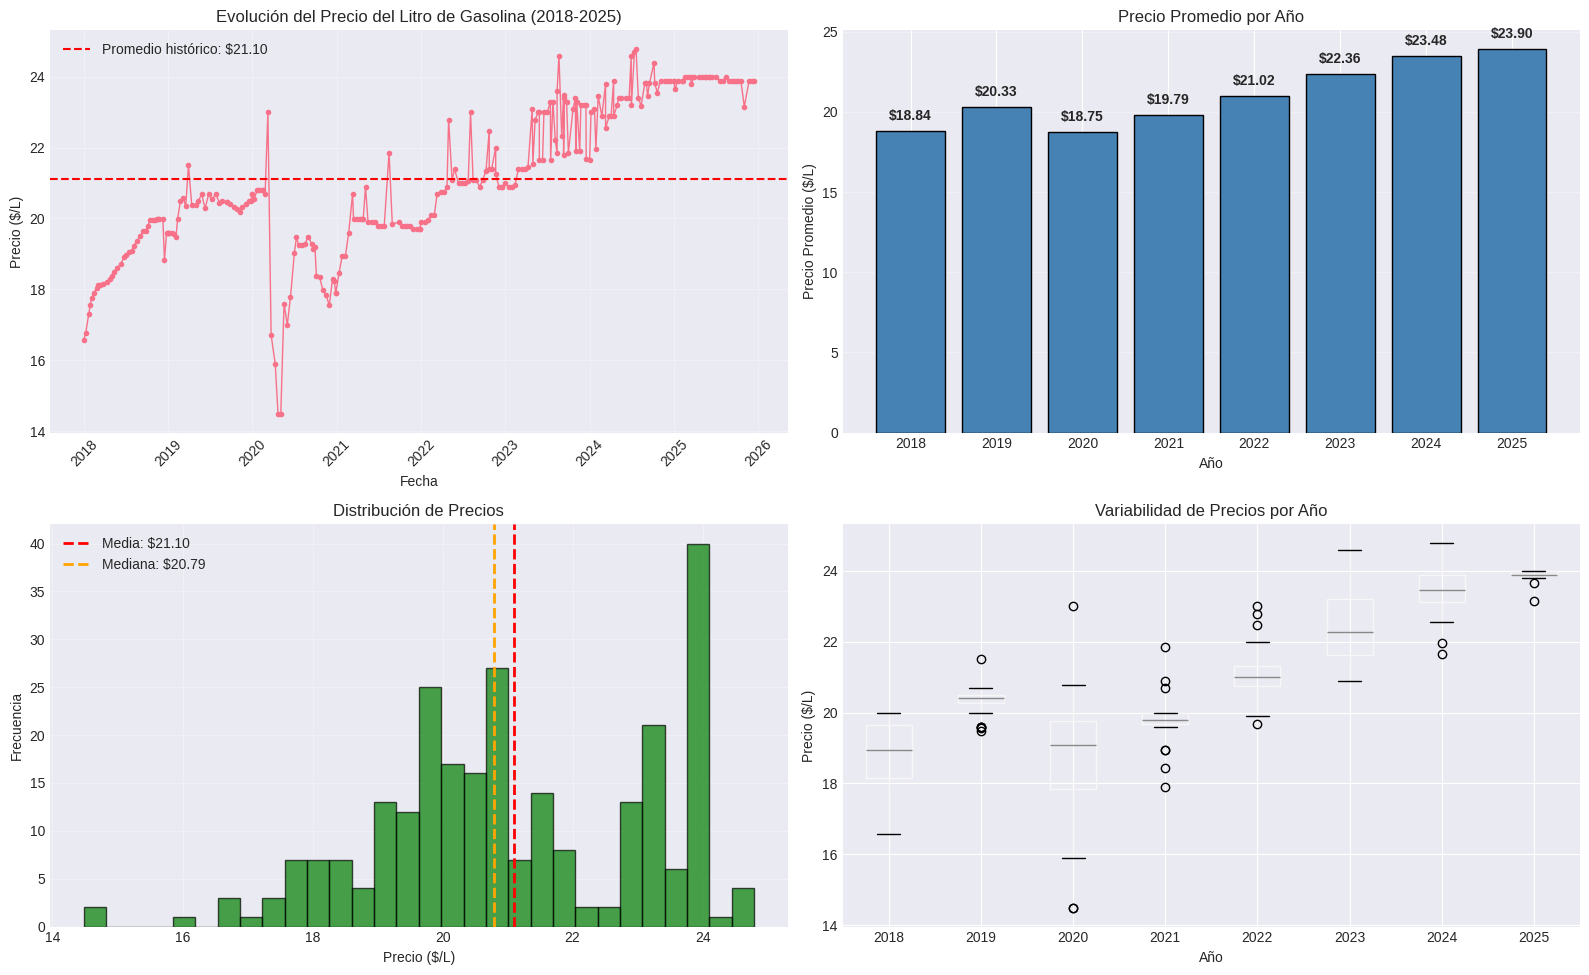

✅ Visualizaciones generadas


In [ ]:
# VISUALIZACIÓN: Evolución del precio
print("\n📊 GENERANDO VISUALIZACIONES DE PRECIO")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Evolución temporal del precio
axes[0, 0].plot(df['Fecha'], df['Precio'], marker='o', linestyle='-', linewidth=1, markersize=3)
axes[0, 0].axhline(precio_promedio_historico, color='red', linestyle='--',
                    label=f'Promedio histórico: ${precio_promedio_historico:.2f}')
axes[0, 0].set_xlabel('Fecha')
axes[0, 0].set_ylabel('Precio ($/L)')
axes[0, 0].set_title('Evolución del Precio del Litro de Gasolina (2018-2025)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Precio promedio por año
precio_anual = df.groupby('Año')['Precio'].mean()
axes[0, 1].bar(precio_anual.index, precio_anual.values, color='steelblue', edgecolor='black')
axes[0, 1].set_xlabel('Año')
axes[0, 1].set_ylabel('Precio Promedio ($/L)')
axes[0, 1].set_title('Precio Promedio por Año')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Agregar valores en las barras
for i, v in enumerate(precio_anual.values):
    axes[0, 1].text(precio_anual.index[i], v + 0.5, f'${v:.2f}',
                     ha='center', va='bottom', fontweight='bold')

# 3. Distribución de precios
axes[1, 0].hist(df['Precio'], bins=30, edgecolor='black', alpha=0.7, color='green')
axes[1, 0].axvline(df['Precio'].mean(), color='red', linestyle='--',
                    linewidth=2, label=f'Media: ${df["Precio"].mean():.2f}')
axes[1, 0].axvline(df['Precio'].median(), color='orange', linestyle='--',
                    linewidth=2, label=f'Mediana: ${df["Precio"].median():.2f}')
axes[1, 0].set_xlabel('Precio ($/L)')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Distribución de Precios')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Boxplot de precios por año
df.boxplot(column='Precio', by='Año', ax=axes[1, 1])
axes[1, 1].set_xlabel('Año')
axes[1, 1].set_ylabel('Precio ($/L)')
axes[1, 1].set_title('Variabilidad de Precios por Año')
axes[1, 1].get_figure().suptitle('')  # Remover título automático

plt.tight_layout()
plt.show()

print("✅ Visualizaciones generadas")

In [ ]:
# INGENIERÍA DE FEATURES - PARTE 4: VARIABLES TEMPORALES
print("\n📅 CALCULANDO VARIABLES TEMPORALES")
print("="*70)

# 1. Extraer componentes de fecha
df['mes'] = df['Fecha'].dt.month
df['trimestre'] = df['Fecha'].dt.quarter
df['dia_semana'] = df['Fecha'].dt.dayofweek  # 0=Lunes, 6=Domingo
df['nombre_dia'] = df['Fecha'].dt.day_name()
df['nombre_mes'] = df['Fecha'].dt.month_name()
df['semana_año'] = df['Fecha'].dt.isocalendar().week

# 2. Días entre recargas (frecuencia de uso)
df['dias_entre_recargas'] = df['Fecha'].diff().dt.days

# 3. Periodo del mes (inicio, medio, fin)
df['periodo_mes'] = pd.cut(df['Fecha'].dt.day,
                            bins=[0, 10, 20, 31],
                            labels=['Inicio', 'Medio', 'Fin'])

# 4. Estacionalidad (temporada del año)
df['estacion'] = df['mes'].map({
    12: 'Invierno', 1: 'Invierno', 2: 'Invierno',
    3: 'Primavera', 4: 'Primavera', 5: 'Primavera',
    6: 'Verano', 7: 'Verano', 8: 'Verano',
    9: 'Otoño', 10: 'Otoño', 11: 'Otoño'
})

# 5. Fin de semana vs entre semana
df['es_fin_semana'] = df['dia_semana'].isin([5, 6])  # Sábado y Domingo

print("✅ Variables temporales creadas:")
print("   - mes, trimestre, dia_semana, nombre_dia, nombre_mes")
print("   - dias_entre_recargas (frecuencia de uso)")
print("   - periodo_mes, estacion, es_fin_semana")

# Verificar
print(f"\n📊 Muestra de variables temporales:")
print(df[['Fecha', 'nombre_dia', 'periodo_mes', 'estacion', 'dias_entre_recargas', 'es_fin_semana']].head(10))

# Estadísticas de frecuencia
print(f"\n⏱️  FRECUENCIA DE RECARGAS:")
print(f"   Promedio de días entre recargas: {df['dias_entre_recargas'].mean():.1f} días")
print(f"   Mediana: {df['dias_entre_recargas'].median():.1f} días")
print(f"   Mínimo: {df['dias_entre_recargas'].min():.0f} días")
print(f"   Máximo: {df['dias_entre_recargas'].max():.0f} días")

# Patrones temporales
print(f"\n📊 RECARGAS POR DÍA DE LA SEMANA:")
recargas_dia = df['nombre_dia'].value_counts().sort_index()
print(recargas_dia)

print(f"\n📊 RECARGAS POR MES:")
recargas_mes = df.groupby('nombre_mes').size()
meses_ordenados = ['January', 'February', 'March', 'April', 'May', 'June',
                   'July', 'August', 'September', 'October', 'November', 'December']
recargas_mes = recargas_mes.reindex(meses_ordenados)
print(recargas_mes)

print(f"\n📊 RECARGAS POR ESTACIÓN:")
print(df['estacion'].value_counts())

print(f"\n🕐 RECARGAS EN FIN DE SEMANA vs ENTRE SEMANA:")
print(df['es_fin_semana'].value_counts())
print(f"   % Fin de semana: {(df['es_fin_semana'].sum() / len(df) * 100):.1f}%")


📅 CALCULANDO VARIABLES TEMPORALES
✅ Variables temporales creadas:
   - mes, trimestre, dia_semana, nombre_dia, nombre_mes
   - dias_entre_recargas (frecuencia de uso)
   - periodo_mes, estacion, es_fin_semana

📊 Muestra de variables temporales:
       Fecha nombre_dia periodo_mes   estacion  dias_entre_recargas  \
0 2017-12-31     Sunday         Fin   Invierno                  NaN   
1 2018-01-09    Tuesday      Inicio   Invierno                  9.0   
2 2018-01-22     Monday         Fin   Invierno                 13.0   
3 2018-01-29     Monday         Fin   Invierno                  7.0   
4 2018-02-04     Sunday      Inicio   Invierno                  6.0   
5 2018-02-12     Monday       Medio   Invierno                  8.0   
6 2018-02-27    Tuesday         Fin   Invierno                 15.0   
7 2018-03-04     Sunday      Inicio  Primavera                  5.0   
8 2018-03-12     Monday       Medio  Primavera                  8.0   
9 2018-03-26     Monday         Fin  Primave


📊 GENERANDO VISUALIZACIONES DE PATRONES TEMPORALES


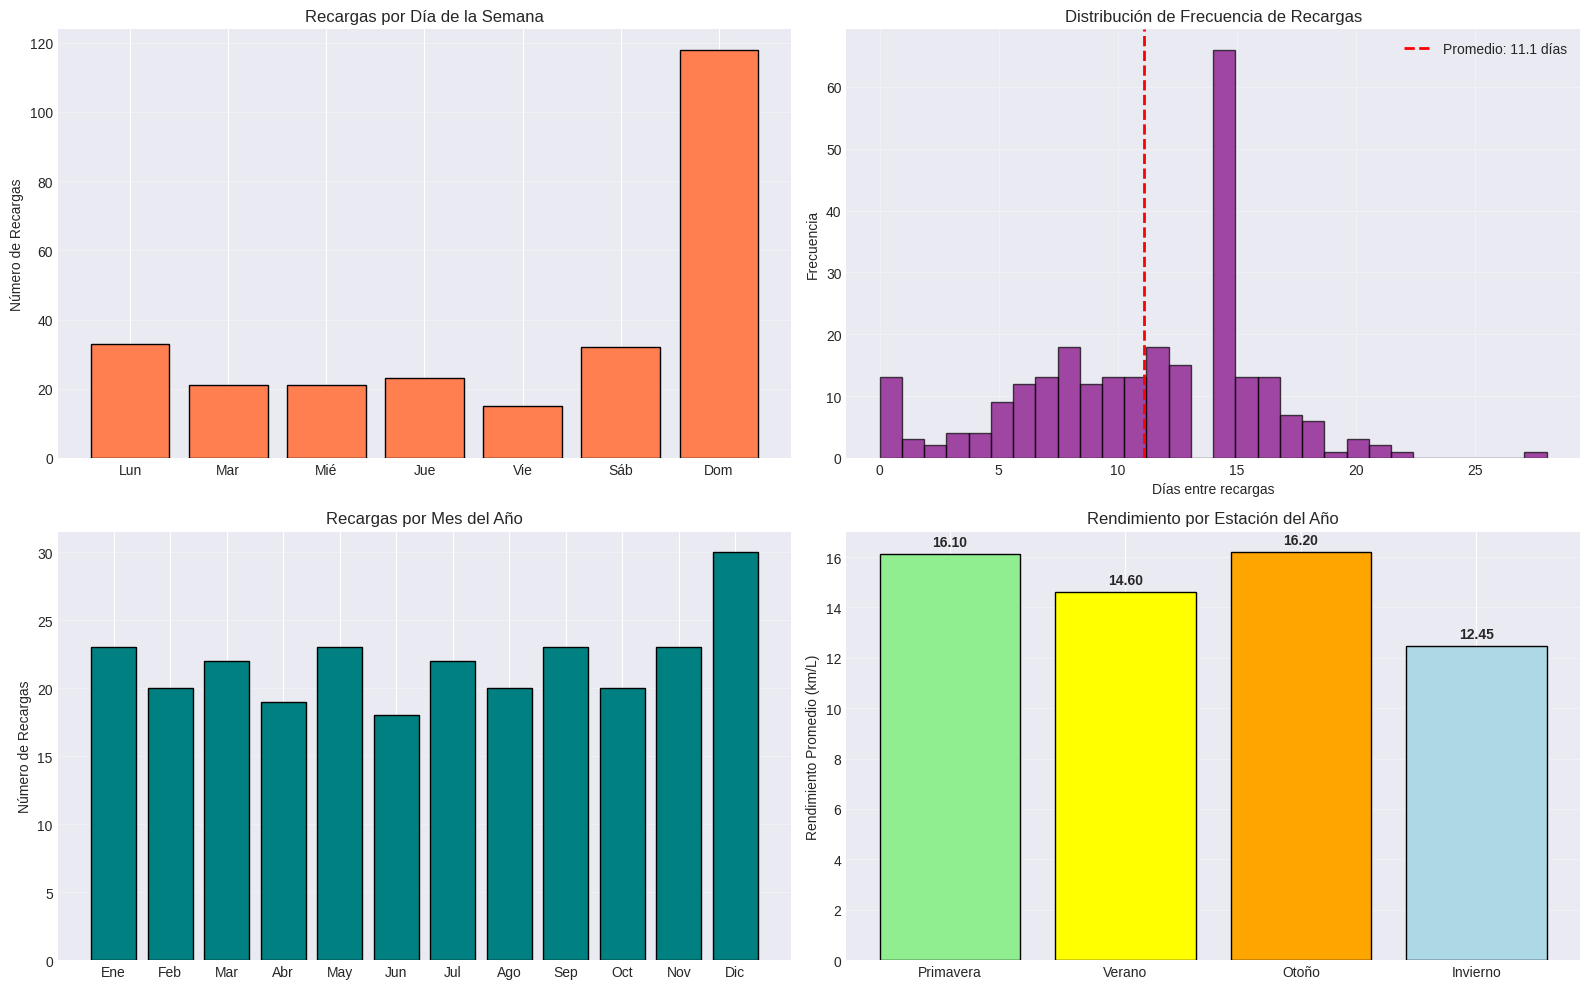

✅ Visualizaciones de patrones temporales generadas


In [ ]:
# VISUALIZACIÓN: Patrones temporales
print("\n📊 GENERANDO VISUALIZACIONES DE PATRONES TEMPORALES")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Frecuencia de recargas por día de la semana
dias_orden = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
recargas_dia_ordenado = df['nombre_dia'].value_counts().reindex(dias_orden)
axes[0, 0].bar(range(7), recargas_dia_ordenado.values, color='coral', edgecolor='black')
axes[0, 0].set_xticks(range(7))
axes[0, 0].set_xticklabels(['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom'])
axes[0, 0].set_ylabel('Número de Recargas')
axes[0, 0].set_title('Recargas por Día de la Semana')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Días entre recargas (histograma)
axes[0, 1].hist(df['dias_entre_recargas'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='purple')
axes[0, 1].axvline(df['dias_entre_recargas'].mean(), color='red', linestyle='--',
                    linewidth=2, label=f'Promedio: {df["dias_entre_recargas"].mean():.1f} días')
axes[0, 1].set_xlabel('Días entre recargas')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].set_title('Distribución de Frecuencia de Recargas')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Recargas por mes del año
recargas_mes_num = df.groupby('mes').size()
meses_nombres = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
axes[1, 0].bar(recargas_mes_num.index, recargas_mes_num.values, color='teal', edgecolor='black')
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].set_xticklabels(meses_nombres)
axes[1, 0].set_ylabel('Número de Recargas')
axes[1, 0].set_title('Recargas por Mes del Año')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Rendimiento por estación del año
rendimiento_estacion = df.groupby('estacion')['rendimiento_kml'].mean().reindex(['Primavera', 'Verano', 'Otoño', 'Invierno'])
axes[1, 1].bar(rendimiento_estacion.index, rendimiento_estacion.values,
               color=['lightgreen', 'yellow', 'orange', 'lightblue'], edgecolor='black')
axes[1, 1].set_ylabel('Rendimiento Promedio (km/L)')
axes[1, 1].set_title('Rendimiento por Estación del Año')
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Agregar valores en las barras
for i, v in enumerate(rendimiento_estacion.values):
    axes[1, 1].text(i, v + 0.2, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ Visualizaciones de patrones temporales generadas")

In [ ]:
# INGENIERÍA DE FEATURES - PARTE 5: AJUSTE POR INFLACIÓN
print("\n💹 AJUSTE DE PRECIOS POR INFLACIÓN")
print("="*70)

# Índices de inflación INPC México (base 2018 = 100)
# Fuente: INEGI - Inflación anual acumulada
# Estos son valores aproximados - idealmente buscarías los oficiales
inflacion_anual = {
    2018: 100.0,   # Año base
    2019: 102.83,  # +2.83%
    2020: 106.40,  # +6.40% acumulado desde 2018
    2021: 114.14,  # +14.14% acumulado
    2022: 122.89,  # +22.89% acumulado
    2023: 127.45,  # +27.45% acumulado
    2024: 132.15,  # +32.15% acumulado (estimado)
    2025: 136.50   # +36.50% acumulado (proyección)
}

# Mapear índice de inflación por año
df['indice_inflacion'] = df['Año'].map(inflacion_anual)

# Calcular precio ajustado a pesos de 2018 (poder adquisitivo real)
# Fórmula: precio_real = precio_nominal / (índice_inflación / 100)
df['precio_real_2018'] = df['Precio'] / (df['indice_inflacion'] / 100)

# Calcular precio ajustado a pesos actuales (2025)
indice_2025 = inflacion_anual[2025]
df['precio_ajustado_2025'] = df['Precio'] * (indice_2025 / df['indice_inflacion'])

# Calcular gasto real (ajustado por inflación)
df['pago_real_2018'] = df['Pago'] / (df['indice_inflacion'] / 100)
df['pago_ajustado_2025'] = df['Pago'] * (indice_2025 / df['indice_inflacion'])

# Calcular costo real por km
df['costo_real_por_km_2018'] = df['pago_real_2018'] / df['km_recorridos']

print("✅ Variables de inflación creadas:")
print("   - precio_real_2018 (poder adquisitivo de 2018)")
print("   - precio_ajustado_2025 (equivalente en pesos de 2025)")
print("   - pago_real_2018, pago_ajustado_2025")
print("   - costo_real_por_km_2018")

# Verificar
print(f"\n📊 Comparación Precio Nominal vs Real (primeros 10 registros):")
print(df[['Fecha', 'Año', 'Precio', 'precio_real_2018', 'precio_ajustado_2025']].head(10))

# Análisis comparativo
print(f"\n📈 ANÁLISIS DE PRECIOS NOMINAL VS REAL:")
print(f"\n{'Año':<6} {'Precio Nominal':<16} {'Precio Real 2018':<18} {'Variación Real':<15}")
print("="*70)

for año in sorted(df['Año'].unique()):
    df_año = df[df['Año'] == año]
    precio_nom = df_año['Precio'].mean()
    precio_real = df_año['precio_real_2018'].mean()
    var_real = ((precio_real - df[df['Año'] == 2018]['precio_real_2018'].mean()) /
                df[df['Año'] == 2018]['precio_real_2018'].mean() * 100)

    print(f"{año:<6} ${precio_nom:>6.2f}/L{'':<6} ${precio_real:>6.2f}/L{'':<8} {var_real:>+6.1f}%")

# Gasto total nominal vs real
gasto_total_nominal = df['Pago'].sum()
gasto_total_real_2018 = df['pago_real_2018'].sum()
gasto_total_ajustado_2025 = df['pago_ajustado_2025'].sum()

print(f"\n💰 GASTO TOTAL (2018-2025):")
print(f"   Nominal (pesos corrientes): ${gasto_total_nominal:,.2f}")
print(f"   Real (pesos de 2018): ${gasto_total_real_2018:,.2f}")
print(f"   Ajustado a 2025: ${gasto_total_ajustado_2025:,.2f}")
print(f"\n💡 Diferencia por inflación: ${gasto_total_ajustado_2025 - gasto_total_nominal:,.2f}")


💹 AJUSTE DE PRECIOS POR INFLACIÓN
✅ Variables de inflación creadas:
   - precio_real_2018 (poder adquisitivo de 2018)
   - precio_ajustado_2025 (equivalente en pesos de 2025)
   - pago_real_2018, pago_ajustado_2025
   - costo_real_por_km_2018

📊 Comparación Precio Nominal vs Real (primeros 10 registros):
       Fecha   Año  Precio  precio_real_2018  precio_ajustado_2025
0 2017-12-31  2018   16.57             16.57              22.61805
1 2018-01-09  2018   16.78             16.78              22.90470
2 2018-01-22  2018   17.31             17.31              23.62815
3 2018-01-29  2018   17.57             17.57              23.98305
4 2018-02-04  2018   17.77             17.77              24.25605
5 2018-02-12  2018   17.90             17.90              24.43350
6 2018-02-27  2018   18.04             18.04              24.62460
7 2018-03-04  2018   18.13             18.13              24.74745
8 2018-03-12  2018   18.13             18.13              24.74745
9 2018-03-26  2018   18


📊 GENERANDO VISUALIZACIONES DE INFLACIÓN


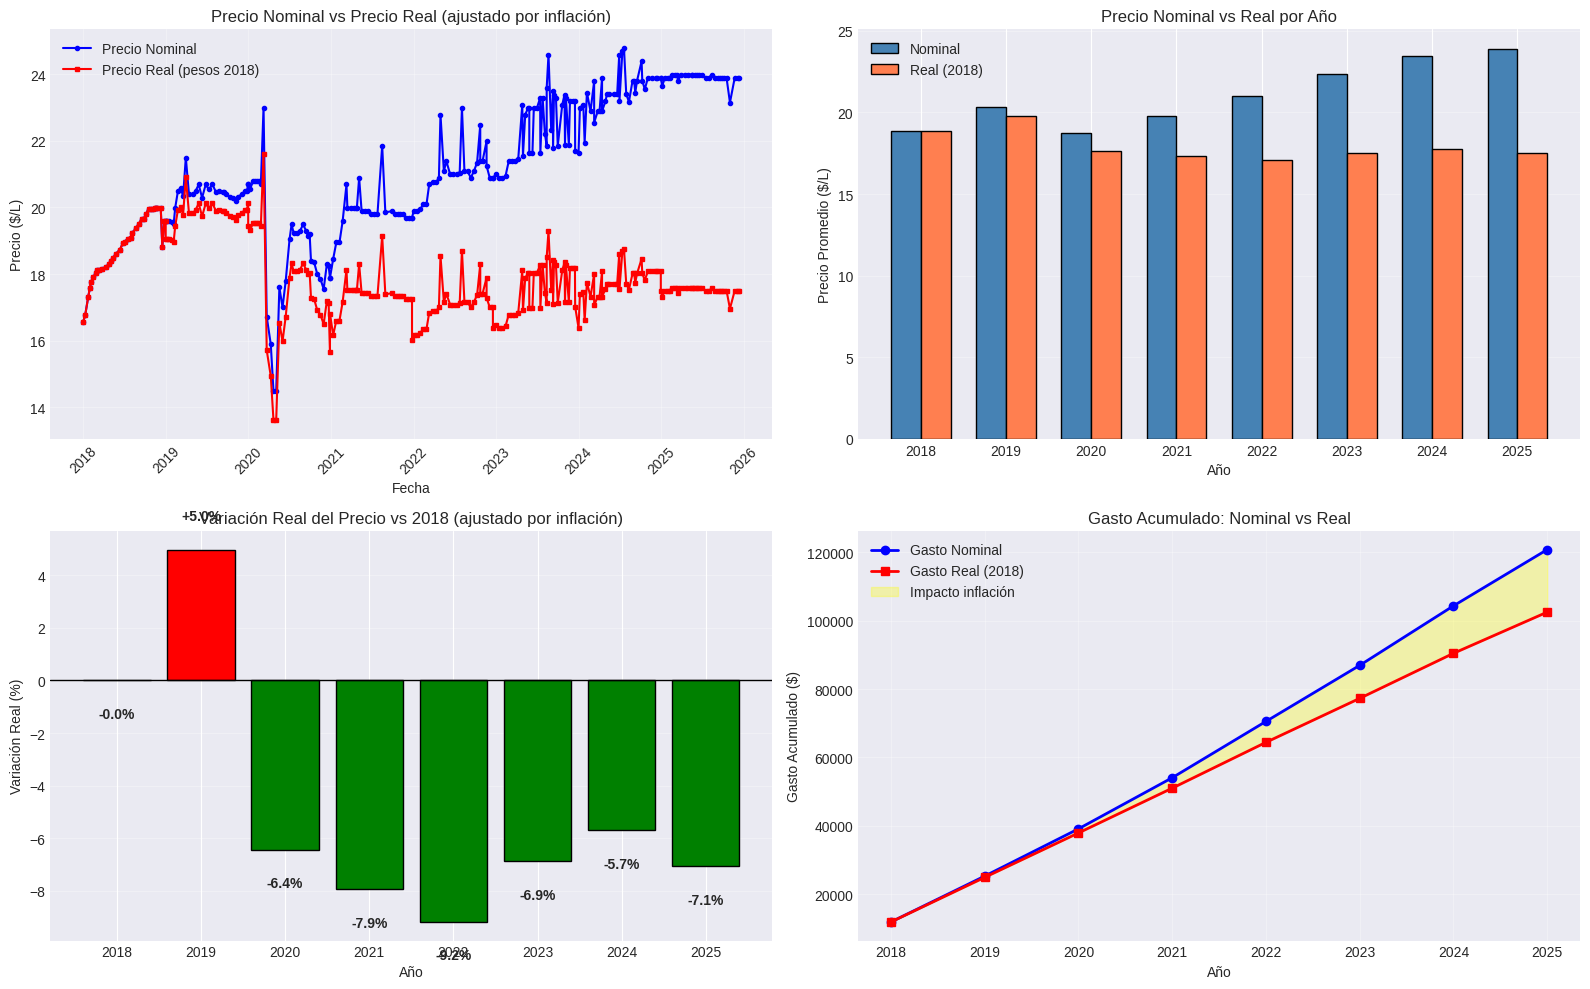

✅ Visualizaciones de inflación generadas


In [ ]:
# VISUALIZACIÓN: Impacto de la inflación
print("\n📊 GENERANDO VISUALIZACIONES DE INFLACIÓN")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Precio Nominal vs Real a lo largo del tiempo
axes[0, 0].plot(df['Fecha'], df['Precio'], marker='o', linestyle='-',
                linewidth=1.5, markersize=3, label='Precio Nominal', color='blue')
axes[0, 0].plot(df['Fecha'], df['precio_real_2018'], marker='s', linestyle='-',
                linewidth=1.5, markersize=3, label='Precio Real (pesos 2018)', color='red')
axes[0, 0].set_xlabel('Fecha')
axes[0, 0].set_ylabel('Precio ($/L)')
axes[0, 0].set_title('Precio Nominal vs Precio Real (ajustado por inflación)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Precio promedio por año (Nominal vs Real)
precio_anual_nom = df.groupby('Año')['Precio'].mean()
precio_anual_real = df.groupby('Año')['precio_real_2018'].mean()

x = np.arange(len(precio_anual_nom))
width = 0.35

axes[0, 1].bar(x - width/2, precio_anual_nom.values, width,
               label='Nominal', color='steelblue', edgecolor='black')
axes[0, 1].bar(x + width/2, precio_anual_real.values, width,
               label='Real (2018)', color='coral', edgecolor='black')
axes[0, 1].set_xlabel('Año')
axes[0, 1].set_ylabel('Precio Promedio ($/L)')
axes[0, 1].set_title('Precio Nominal vs Real por Año')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(precio_anual_nom.index)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Variación real del precio (% respecto a 2018)
precio_base_2018 = df[df['Año'] == 2018]['precio_real_2018'].mean()
variacion_real_anual = ((precio_anual_real - precio_base_2018) / precio_base_2018 * 100)

axes[1, 0].bar(variacion_real_anual.index, variacion_real_anual.values,
               color=['green' if x < 0 else 'red' for x in variacion_real_anual.values],
               edgecolor='black')
axes[1, 0].axhline(0, color='black', linewidth=1)
axes[1, 0].set_xlabel('Año')
axes[1, 0].set_ylabel('Variación Real (%)')
axes[1, 0].set_title('Variación Real del Precio vs 2018 (ajustado por inflación)')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Agregar valores en las barras
for i, v in enumerate(variacion_real_anual.values):
    axes[1, 0].text(variacion_real_anual.index[i], v + (1 if v > 0 else -1),
                     f'{v:+.1f}%', ha='center', va='bottom' if v > 0 else 'top',
                     fontweight='bold')

# 4. Impacto acumulado de la inflación
gasto_acumulado_nom = df.groupby('Año')['Pago'].sum().cumsum()
gasto_acumulado_real = df.groupby('Año')['pago_real_2018'].sum().cumsum()

axes[1, 1].plot(gasto_acumulado_nom.index, gasto_acumulado_nom.values,
                marker='o', linewidth=2, label='Gasto Nominal', color='blue')
axes[1, 1].plot(gasto_acumulado_real.index, gasto_acumulado_real.values,
                marker='s', linewidth=2, label='Gasto Real (2018)', color='red')
axes[1, 1].fill_between(gasto_acumulado_nom.index,
                         gasto_acumulado_nom.values,
                         gasto_acumulado_real.values,
                         alpha=0.3, color='yellow', label='Impacto inflación')
axes[1, 1].set_xlabel('Año')
axes[1, 1].set_ylabel('Gasto Acumulado ($)')
axes[1, 1].set_title('Gasto Acumulado: Nominal vs Real')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visualizaciones de inflación generadas")

In [ ]:
# EXPORTAR DATASET COMPLETO CON TODAS LAS FEATURES
print("\n💾 EXPORTANDO DATASET ENRIQUECIDO")
print("="*70)

# Verificar todas las columnas creadas
print(f"📋 Columnas totales en el dataset: {len(df.columns)}")
print(f"\nListado de features:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2d}. {col}")

# Reordenar columnas para mejor legibilidad
columnas_ordenadas = [
    # Identificadores y fecha
    'Fecha', 'Año', 'mes', 'trimestre', 'nombre_mes', 'dia_semana', 'nombre_dia',
    'semana_año', 'periodo_mes', 'estacion', 'es_fin_semana',

    # Variables originales
    'Kilometros', 'Litros', 'Pago', 'Precio',

    # Variables calculadas - Distancia
    'km_recorridos', 'km_acumulados', 'dias_entre_recargas',

    # Variables calculadas - Eficiencia
    'rendimiento_kml', 'eficiencia_relativa', 'es_outlier', 'tipo_recarga',

    # Variables calculadas - Costo
    'costo_por_km', 'precio_cambio_pct', 'precio_vs_historico',

    # Variables calculadas - Inflación
    'indice_inflacion', 'precio_real_2018', 'precio_ajustado_2025',
    'pago_real_2018', 'pago_ajustado_2025', 'costo_real_por_km_2018'
]

df_ordenado = df[columnas_ordenadas]

# Exportar dataset completo
nombre_archivo_completo = 'gasolina_dataset_completo.csv'
df_ordenado.to_csv(nombre_archivo_completo, index=False, encoding='utf-8-sig')

print(f"\n✅ Dataset completo exportado: {nombre_archivo_completo}")
print(f"📊 Dimensiones: {df_ordenado.shape[0]} registros × {df_ordenado.shape[1]} variables")

# Descargar
from google.colab import files
files.download(nombre_archivo_completo)

print(f"\n✅ Descarga iniciada")


💾 EXPORTANDO DATASET ENRIQUECIDO
📋 Columnas totales en el dataset: 32

Listado de features:
    1. Kilometros
    2. Litros
    3. Pago
    4. Precio
    5. Fecha
    6. Año
    7. km_diff
    8. km_recorridos
    9. km_acumulados
   10. rendimiento_kml
   11. eficiencia_relativa
   12. es_outlier
   13. tipo_recarga
   14. costo_por_km
   15. precio_cambio_pct
   16. precio_vs_historico
   17. mes
   18. trimestre
   19. dia_semana
   20. nombre_dia
   21. nombre_mes
   22. semana_año
   23. dias_entre_recargas
   24. periodo_mes
   25. estacion
   26. es_fin_semana
   27. indice_inflacion
   28. precio_real_2018
   29. precio_ajustado_2025
   30. pago_real_2018
   31. pago_ajustado_2025
   32. costo_real_por_km_2018

✅ Dataset completo exportado: gasolina_dataset_completo.csv
📊 Dimensiones: 263 registros × 31 variables


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Descarga iniciada


In [ ]:
# RESUMEN EJECUTIVO DEL ANÁLISIS
print("\n" + "="*70)
print("📊 RESUMEN EJECUTIVO - ANÁLISIS DE CONSUMO DE GASOLINA 2018-2025")
print("="*70)

print(f"\n📅 PERIODO DE ANÁLISIS:")
print(f"   Fecha inicial: {df['Fecha'].min().date()}")
print(f"   Fecha final: {df['Fecha'].max().date()}")
print(f"   Duración: {(df['Fecha'].max() - df['Fecha'].min()).days / 365.25:.1f} años")
print(f"   Total de recargas: {len(df)}")

print(f"\n🚗 KILOMETRAJE:")
print(f"   Km inicial: {df['Kilometros'].iloc[0]:,.0f}")
print(f"   Km final: {df['Kilometros'].iloc[-1]:,.0f}")
print(f"   Total recorrido: {df['km_acumulados'].iloc[-1]:,.0f} km")
print(f"   Promedio km/año: {df['km_acumulados'].iloc[-1] / ((df['Fecha'].max() - df['Fecha'].min()).days / 365.25):,.0f} km")

print(f"\n⛽ CONSUMO:")
print(f"   Total de litros: {df['Litros'].sum():,.2f} L")
print(f"   Promedio por recarga: {df['Litros'].mean():.2f} L")
print(f"   Rendimiento promedio: {df['rendimiento_kml'].mean():.2f} km/L")
print(f"   Rendimiento mediana: {df['rendimiento_kml'].median():.2f} km/L")
print(f"   Mejor rendimiento: {df['rendimiento_kml'].max():.2f} km/L")
print(f"   Peor rendimiento: {df['rendimiento_kml'].min():.2f} km/L")

print(f"\n💰 COSTOS NOMINALES:")
print(f"   Gasto total: ${df['Pago'].sum():,.2f}")
print(f"   Promedio por recarga: ${df['Pago'].mean():.2f}")
print(f"   Precio mínimo: ${df['Precio'].min():.2f}/L ({df.loc[df['Precio'].idxmin(), 'Fecha'].date()})")
print(f"   Precio máximo: ${df['Precio'].max():.2f}/L ({df.loc[df['Precio'].idxmax(), 'Fecha'].date()})")
print(f"   Precio promedio histórico: ${df['Precio'].mean():.2f}/L")

print(f"\n💹 COSTOS AJUSTADOS POR INFLACIÓN:")
print(f"   Gasto total (pesos 2018): ${df['pago_real_2018'].sum():,.2f}")
print(f"   Gasto total (pesos 2025): ${df['pago_ajustado_2025'].sum():,.2f}")
print(f"   Impacto de inflación: ${df['pago_ajustado_2025'].sum() - df['Pago'].sum():,.2f}")
print(f"   Precio real promedio 2018: ${df[df['Año']==2018]['precio_real_2018'].mean():.2f}/L")
print(f"   Precio real promedio 2025: ${df[df['Año']==2025]['precio_real_2018'].mean():.2f}/L")

print(f"\n⏱️  FRECUENCIA:")
print(f"   Promedio días entre recargas: {df['dias_entre_recargas'].mean():.1f} días")
print(f"   Mediana días entre recargas: {df['dias_entre_recargas'].median():.1f} días")

print(f"\n📊 PATRONES DE USO:")
print(f"   Día más frecuente: {df['nombre_dia'].mode()[0]}")
print(f"   Mes más frecuente: {df['nombre_mes'].mode()[0]}")
print(f"   % Recargas en fin de semana: {(df['es_fin_semana'].sum() / len(df) * 100):.1f}%")

print(f"\n📈 TENDENCIAS:")
incremento_precio_nominal = ((df[df['Año']==2025]['Precio'].mean() -
                              df[df['Año']==2018]['Precio'].mean()) /
                              df[df['Año']==2018]['Precio'].mean() * 100)
incremento_precio_real = ((df[df['Año']==2025]['precio_real_2018'].mean() -
                           df[df['Año']==2018]['precio_real_2018'].mean()) /
                           df[df['Año']==2018]['precio_real_2018'].mean() * 100)

print(f"   Incremento precio nominal 2018-2025: {incremento_precio_nominal:+.1f}%")
print(f"   Incremento precio REAL 2018-2025: {incremento_precio_real:+.1f}%")
print(f"   Outliers detectados: {df['es_outlier'].sum()} ({df['es_outlier'].sum()/len(df)*100:.1f}%)")

print("\n" + "="*70)
print("✅ ANÁLISIS COMPLETADO")
print("="*70)


📊 RESUMEN EJECUTIVO - ANÁLISIS DE CONSUMO DE GASOLINA 2018-2025

📅 PERIODO DE ANÁLISIS:
   Fecha inicial: 2017-12-31
   Fecha final: 2025-12-13
   Duración: 8.0 años
   Total de recargas: 263

🚗 KILOMETRAJE:
   Km inicial: 42,998
   Km final: 114,043
   Total recorrido: 71,045 km
   Promedio km/año: 8,936 km

⛽ CONSUMO:
   Total de litros: 5,693.28 L
   Promedio por recarga: 21.65 L
   Rendimiento promedio: 14.78 km/L
   Rendimiento mediana: 12.87 km/L
   Mejor rendimiento: 79.05 km/L
   Peor rendimiento: -11.67 km/L

💰 COSTOS NOMINALES:
   Gasto total: $120,774.62
   Promedio por recarga: $459.22
   Precio mínimo: $14.48/L (2020-04-21)
   Precio máximo: $24.79/L (2024-07-20)
   Precio promedio histórico: $21.10/L

💹 COSTOS AJUSTADOS POR INFLACIÓN:
   Gasto total (pesos 2018): $102,494.02
   Gasto total (pesos 2025): $139,904.34
   Impacto de inflación: $19,129.72
   Precio real promedio 2018: $18.84/L
   Precio real promedio 2025: $17.51/L

⏱️  FRECUENCIA:
   Promedio días entre reca

In [ ]:
# PREPARACIÓN FINAL PARA POWER BI
print("\n🔧 PREPARANDO DATASET ÓPTIMO PARA POWER BI")
print("="*70)

# Crear dataset específico para Power BI
df_powerbi = df_ordenado.copy()

# 1. Convertir booleanos a texto (Power BI es más amigable con texto)
df_powerbi['outlier_flag'] = df_powerbi['es_outlier'].map({True: 'Sí', False: 'No'})
df_powerbi['fin_semana'] = df_powerbi['es_fin_semana'].map({True: 'Fin de semana', False: 'Entre semana'})

# 2. Asegurar que fechas estén en formato correcto
df_powerbi['Fecha'] = pd.to_datetime(df_powerbi['Fecha'])

# 3. Crear columna de periodo para análisis comparativo
df_powerbi['periodo_gobierno'] = df_powerbi['Año'].apply(
    lambda x: '2018 (Pre-cambio)' if x == 2018 else
              '2019-2020 (Inicio + Pandemia)' if x in [2019, 2020] else
              '2021-2023 (Post-pandemia)' if x in [2021, 2022, 2023] else
              '2024-2025 (Control precios)'
)

# 4. Redondear decimales para mejor visualización
columnas_numericas = ['rendimiento_kml', 'costo_por_km', 'precio_real_2018',
                      'precio_ajustado_2025', 'eficiencia_relativa']
for col in columnas_numericas:
    df_powerbi[col] = df_powerbi[col].round(2)

# 5. Crear ID único para drill-through
df_powerbi['ID_Recarga'] = range(1, len(df_powerbi) + 1)

# 6. Verificar tipos de datos
print("\n📋 VERIFICACIÓN DE TIPOS DE DATOS:")
print(df_powerbi.dtypes)

# 7. Verificar que no haya valores infinitos o NaN problemáticos
print(f"\n🔍 VERIFICACIÓN DE CALIDAD:")
print(f"   Valores nulos: {df_powerbi.isnull().sum().sum()}")
print(f"   Valores infinitos: {np.isinf(df_powerbi.select_dtypes(include=[np.number])).sum().sum()}")

# 8. Exportar versión para Power BI
nombre_powerbi = 'gasolina_powerbi.csv'
df_powerbi.to_csv(nombre_powerbi, index=False, encoding='utf-8-sig')

print(f"\n✅ Dataset para Power BI exportado: {nombre_powerbi}")
print(f"📊 Dimensiones: {df_powerbi.shape[0]} registros × {df_powerbi.shape[1]} columnas")

# Descargar
files.download(nombre_powerbi)

print(f"\n🎯 LISTO PARA POWER BI")
print("="*70)

# Mostrar muestra
print(f"\n📋 Muestra del dataset (primeras 5 filas):")
print(df_powerbi.head())


🔧 PREPARANDO DATASET ÓPTIMO PARA POWER BI

📋 VERIFICACIÓN DE TIPOS DE DATOS:
Fecha                     datetime64[ns]
Año                                int64
mes                                int32
trimestre                          int32
nombre_mes                        object
dia_semana                         int32
nombre_dia                        object
semana_año                        UInt32
periodo_mes                     category
estacion                          object
es_fin_semana                       bool
Kilometros                       float64
Litros                           float64
Pago                             float64
Precio                           float64
km_recorridos                    float64
km_acumulados                    float64
dias_entre_recargas              float64
rendimiento_kml                  float64
eficiencia_relativa              float64
es_outlier                          bool
tipo_recarga                    category
costo_por_km        

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎯 LISTO PARA POWER BI

📋 Muestra del dataset (primeras 5 filas):
       Fecha   Año  mes  trimestre nombre_mes  dia_semana nombre_dia  \
0 2017-12-31  2018   12          4   December           6     Sunday   
1 2018-01-09  2018    1          1    January           1    Tuesday   
2 2018-01-22  2018    1          1    January           0     Monday   
3 2018-01-29  2018    1          1    January           0     Monday   
4 2018-02-04  2018    2          1   February           6     Sunday   

   semana_año periodo_mes  estacion  ...  indice_inflacion  precio_real_2018  \
0          52         Fin  Invierno  ...             100.0             16.57   
1           2      Inicio  Invierno  ...             100.0             16.78   
2           4         Fin  Invierno  ...             100.0             17.31   
3           5         Fin  Invierno  ...             100.0             17.57   
4           5      Inicio  Invierno  ...             100.0             17.77   

   precio_ajustado_2